In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Iterable
import pickle
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def normalize_unicode(text: str) -> str:
    """Normalize unicode while preserving substantive text."""
    if pd.isna(text):
        return ""
    return unicodedata.normalize("NFKC", str(text))


def normalize_whitespace(text: str) -> str:
    """Collapse excess whitespace."""
    if pd.isna(text):
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()


def clean_slogan_text(text: str) -> str:
    """
    Clean a slogan while preserving substantive wording.

    Notes
    -----
    - Keeps punctuation because punctuation can be part of slogan style.
    - Removes surrounding whitespace and normalizes unicode.
    - Removes only wrapping quotation marks, not internal quotation marks.
    """
    text = normalize_unicode(text)
    text = normalize_whitespace(text)

    # Remove symmetric wrapping quotation marks only.
    text = re.sub(r"^['\"“”‘’]+|['\"“”‘’]+$", "", text).strip()
    text = normalize_whitespace(text)

    return text


def rough_word_count(text: str) -> int:
    """Approximate word count for slogans."""
    text = clean_slogan_text(text)
    if not text:
        return 0
    return len(re.findall(r"\b[\w']+\b", text))


def char_count(text: str) -> int:
    """Character count after cleaning."""
    return len(clean_slogan_text(text))


def line_count(text: str) -> int:
    """Number of non-empty lines."""
    if pd.isna(text):
        return 0
    return len([ln for ln in str(text).splitlines() if ln.strip()])


def looks_like_multiple_slogans(text: str) -> bool:
    """
    Heuristic flag for outputs that look like multiple slogans.
    Human data may occasionally contain punctuation or lists; we do not filter by this.
    """
    if pd.isna(text):
        return False

    raw = str(text).strip()
    lines = [ln.strip() for ln in raw.splitlines() if ln.strip()]

    if len(lines) > 1:
        return True

    if re.search(r"(^|\n)\s*(\d+[\.\)]|[-*•])\s+", raw):
        return True

    # Multiple quoted slogans in one cell.
    if len(re.findall(r'["“][^"”]+["”]', raw)) > 1:
        return True

    return False


def has_slogan_commentary(text: str) -> bool:
    """
    Heuristic flag for commentary rather than a slogan.
    This is diagnostic only.
    """
    text = clean_slogan_text(text).lower()
    if not text:
        return False

    commentary_patterns = [
        r"^slogan:",
        r"^here('s| is)\b",
        r"^my slogan",
        r"^option\s+\d+",
    ]

    return any(re.search(p, text) for p in commentary_patterns)

In [3]:
@dataclass
class SloganCorpus:
    """
    Container for human slogan data.

    Core design:
    - `records` stores one row per human slogan.
    - `participant_id` identifies the human participant.
    - `order` preserves the order in which slogans were produced by each participant.
    - Exact duplicates are retained because duplicates are part of the redundancy signal.
    - The task has one condition for now: smartphone.
    """
    records: pd.DataFrame
    source_path: str
    metadata: Dict = field(default_factory=dict)

    def __post_init__(self):
        required = {
            "slogan_id",
            "participant_id",
            "condition_id",
            "condition_label",
            "product",
            "order",
            "text_raw",
            "text",
            "word_count_reported",
            "word_count",
            "char_count",
            "created_at_raw",
        }
        missing = required - set(self.records.columns)
        if missing:
            raise ValueError(f"records is missing required columns: {sorted(missing)}")

    @property
    def n_slogans(self) -> int:
        return len(self.records)

    @property
    def n_participants(self) -> int:
        return self.records["participant_id"].nunique()

    @property
    def n_conditions(self) -> int:
        return self.records["condition_id"].nunique()

    def to_pickle(self, path: str | Path) -> None:
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(self, f, protocol=pickle.HIGHEST_PROTOCOL)

    @staticmethod
    def from_pickle(path: str | Path) -> "SloganCorpus":
        with open(path, "rb") as f:
            return pickle.load(f)

    def get_records(
        self,
        participant_ids: Optional[Iterable[str]] = None,
        condition_ids: Optional[Iterable[str]] = None,
        min_words: Optional[int] = None,
        max_words: Optional[int] = None,
    ) -> pd.DataFrame:
        """Return filtered records as a copy."""
        df = self.records

        if participant_ids is not None:
            df = df[df["participant_id"].isin(list(participant_ids))]

        if condition_ids is not None:
            df = df[df["condition_id"].isin(list(condition_ids))]

        if min_words is not None:
            df = df[df["word_count"] >= min_words]

        if max_words is not None:
            df = df[df["word_count"] <= max_words]

        return df.copy()

    def participant_summary(self) -> pd.DataFrame:
        """Summarize number and length of slogans per participant."""
        return (
            self.records
            .groupby("participant_id", as_index=False)
            .agg(
                n_slogans=("text", "size"),
                n_unique_slogans=("text", "nunique"),
                min_order=("order", "min"),
                max_order=("order", "max"),
                mean_words=("word_count", "mean"),
                median_words=("word_count", "median"),
                min_words=("word_count", "min"),
                max_words=("word_count", "max"),
                n_over_6_words=("over_6_words", "sum"),
                created_at_values=("created_at_raw", lambda x: ",".join(sorted(set(map(str, x))))),
            )
            .sort_values(["n_slogans", "participant_id"], ascending=[False, True])
            .reset_index(drop=True)
        )

    def condition_summary(self) -> pd.DataFrame:
        """Summarize response counts and slogan lengths by condition."""
        return (
            self.records
            .groupby(["condition_id", "condition_label", "product"], as_index=False)
            .agg(
                n_slogans=("text", "size"),
                n_unique_slogans=("text", "nunique"),
                n_participants=("participant_id", "nunique"),
                mean_slogans_per_participant=("participant_id", lambda x: len(x) / x.nunique()),
                mean_words=("word_count", "mean"),
                median_words=("word_count", "median"),
                min_words=("word_count", "min"),
                max_words=("word_count", "max"),
                n_over_6_words=("over_6_words", "sum"),
                over_6_word_rate=("over_6_words", "mean"),
            )
            .sort_values("condition_id")
            .reset_index(drop=True)
        )

    def sample_one_slogan_per_participant(
        self,
        random_state: int = 42,
        condition_id: str = "smartphone",
    ) -> pd.DataFrame:
        """
        Return one sampled slogan per participant.

        This is useful for later matched human-vs-AI bootstrapping if the
        desired human unit is one creative product per person.
        """
        df = self.get_records(condition_ids=[condition_id])

        sampled = (
            df.groupby("participant_id", group_keys=False)
              .sample(n=1, random_state=random_state)
              .sort_values("participant_id")
              .reset_index(drop=True)
        )

        return sampled

    def show_examples(
        self,
        n: int = 20,
        random_state: int = 42,
        participant_id: Optional[str] = None,
    ) -> None:
        """Print sample slogans."""
        df = self.records.copy()

        if participant_id is not None:
            df = df[df["participant_id"] == participant_id]

        if df.empty:
            print("No records found.")
            return

        sample = df.sample(n=min(n, len(df)), random_state=random_state)

        for i, (_, row) in enumerate(sample.iterrows(), start=1):
            print("=" * 80)
            print(f"EXAMPLE {i}")
            print(f"participant_id={row['participant_id']} | order={row['order']} | words={row['word_count']}")
            print("-" * 80)
            print(row["text"])

In [4]:
def load_slogan_corpus(
    csv_path: str | Path = "human_data/sloganData/slogans.csv",
    condition_id: str = "smartphone",
    condition_label: str = "Smartphone",
    product: str = "smartphone",
) -> SloganCorpus:
    """
    Load human slogan data from CSV into a reusable corpus object.

    Expected columns:
    - prolificId
    - order
    - text
    - wordCount
    - createdAt
    """
    csv_path = Path(csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"Missing slogans CSV: {csv_path}")

    raw = pd.read_csv(csv_path)

    expected = {"prolificId", "order", "text", "wordCount", "createdAt"}
    missing = expected - set(raw.columns)
    if missing:
        raise ValueError(f"Input CSV is missing expected columns: {sorted(missing)}")

    df = raw.copy()

    df["participant_id"] = df["prolificId"].astype(str)
    df["condition_id"] = condition_id
    df["condition_label"] = condition_label
    df["product"] = product

    df["order"] = pd.to_numeric(df["order"], errors="coerce").astype("Int64")
    df["text_raw"] = df["text"]
    df["text"] = df["text_raw"].map(clean_slogan_text)

    df["word_count_reported"] = pd.to_numeric(df["wordCount"], errors="coerce").astype("Int64")
    df["word_count"] = df["text"].map(rough_word_count).astype(int)
    df["char_count"] = df["text"].map(char_count).astype(int)
    df["line_count"] = df["text_raw"].map(line_count).astype(int)

    df["created_at_raw"] = df["createdAt"]

    df["empty_text"] = df["text"].eq("")
    df["over_6_words"] = df["word_count"] > 6
    df["reported_word_count_mismatch"] = (
        df["word_count_reported"].notna()
        & (df["word_count_reported"].astype("float") != df["word_count"].astype("float"))
    )
    df["looks_like_multiple_slogans"] = df["text_raw"].map(looks_like_multiple_slogans)
    df["has_commentary"] = df["text_raw"].map(has_slogan_commentary)

    df["valid_slogan_heuristic"] = (
        (~df["empty_text"])
        & (df["word_count"].between(1, 6))
        & (~df["looks_like_multiple_slogans"])
        & (~df["has_commentary"])
    )

    # Preserve original row order while also sorting within participant by provided order.
    df.insert(0, "source_row_idx", np.arange(len(df), dtype=int))

    # Stable slogan id after loading. This is instance-level, not unique-text-level.
    df.insert(0, "slogan_id", np.arange(len(df), dtype=int))

    # Reorder columns.
    cols = [
        "slogan_id",
        "source_row_idx",
        "participant_id",
        "condition_id",
        "condition_label",
        "product",
        "order",
        "text_raw",
        "text",
        "word_count_reported",
        "word_count",
        "char_count",
        "line_count",
        "created_at_raw",
        "empty_text",
        "over_6_words",
        "reported_word_count_mismatch",
        "looks_like_multiple_slogans",
        "has_commentary",
        "valid_slogan_heuristic",
    ]

    records = df[cols].sort_values(
        ["participant_id", "order", "source_row_idx"],
        na_position="last"
    ).reset_index(drop=True)

    # Reassign slogan_id after canonical sorting.
    records["slogan_id"] = np.arange(len(records), dtype=int)

    metadata = {
        "source_path": str(csv_path),
        "condition_id": condition_id,
        "condition_label": condition_label,
        "product": product,
        "n_slogans": int(len(records)),
        "n_participants": int(records["participant_id"].nunique()),
        "n_unique_slogans": int(records["text"].nunique()),
        "created_by": "load_slogan_corpus",
        "notes": (
            "Exact duplicate slogans are retained. Validity flags are diagnostic only; "
            "main benchmark should not filter unless explicitly decided later."
        ),
    }

    corpus = SloganCorpus(
        records=records,
        source_path=str(csv_path),
        metadata=metadata,
    )

    print("Loaded slogan corpus")
    print(f"  Source:              {csv_path}")
    print(f"  Total slogans:       {corpus.n_slogans:,}")
    print(f"  Participants:        {corpus.n_participants:,}")
    print(f"  Unique slogans:      {records['text'].nunique():,}")
    print(f"  Condition(s):        {records['condition_id'].unique().tolist()}")
    print()
    print("Validity diagnostics")
    print(f"  Empty text:          {int(records['empty_text'].sum()):,}")
    print(f"  >6 words:            {int(records['over_6_words'].sum()):,}")
    print(f"  Word-count mismatch: {int(records['reported_word_count_mismatch'].sum()):,}")
    print(f"  Multiple-like:       {int(records['looks_like_multiple_slogans'].sum()):,}")
    print(f"  Commentary-like:     {int(records['has_commentary'].sum()):,}")

    return corpus


slogan_corpus = load_slogan_corpus(
    csv_path="human_data/sloganData/slogans.csv",
    condition_id="smartphone",
    condition_label="Smartphone",
    product="smartphone",
)

slogan_corpus.records.head(20)

Loaded slogan corpus
  Source:              human_data/sloganData/slogans.csv
  Total slogans:       659
  Participants:        95
  Unique slogans:      650
  Condition(s):        ['smartphone']

Validity diagnostics
  Empty text:          0
  >6 words:            1
  Word-count mismatch: 11
  Multiple-like:       0
  Commentary-like:     0


,slogan_id,source_row_idx,participant_id,condition_id,condition_label,product,order,text_raw,text,word_count_reported,word_count,char_count,line_count,created_at_raw,empty_text,over_6_words,reported_word_count_mismatch,looks_like_multiple_slogans,has_commentary,valid_slogan_heuristic
0,0,0,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,1,The future right in your pocket.,The future right in your pocket.,6,6,32,1,15:53.4,False,False,False,False,False,True
1,1,1,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,2,A phone for a new age.,A phone for a new age.,6,6,22,1,15:53.4,False,False,False,False,False,True
2,2,2,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,3,Slim. Sleek. Smartphone.,Slim. Sleek. Smartphone.,3,3,24,1,15:53.4,False,False,False,False,False,True
3,3,3,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,4,Be smart. Get this phone.,Be smart. Get this phone.,5,5,25,1,15:53.4,False,False,False,False,False,True
4,4,4,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,5,Smartphones just got a genius upgrade.,Smartphones just got a genius upgrade.,6,6,38,1,15:53.4,False,False,False,False,False,True
5,5,5,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,6,The cutting edge of what's possible.,The cutting edge of what's possible.,6,6,36,1,15:53.4,False,False,False,False,False,True
6,6,6,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,7,A phone that's complex as you,A phone that's complex as you,6,6,29,1,15:53.4,False,False,False,False,False,True
7,7,7,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,8,One phone to rule them all.,One phone to rule them all.,6,6,27,1,15:53.4,False,False,False,False,False,True
8,8,8,562d4849733ea000111635ca,smartphone,Smartphone,smartphone,1,Life in your hands,Life in your hands,4,4,18,1,16:24.9,False,False,False,False,False,True
9,9,9,562d4849733ea000111635ca,smartphone,Smartphone,smartphone,2,The future and universe,The future and universe,4,4,23,1,16:24.9,False,False,False,False,False,True


In [5]:
condition_summary = slogan_corpus.condition_summary()
participant_summary = slogan_corpus.participant_summary()

display(condition_summary)
display(participant_summary.head(20))

print("Participant slogan-count distribution")
display(participant_summary["n_slogans"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

print("\nWord-count distribution")
display(slogan_corpus.records["word_count"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

,condition_id,condition_label,product,n_slogans,n_unique_slogans,n_participants,mean_slogans_per_participant,mean_words,median_words,min_words,max_words,n_over_6_words,over_6_word_rate
0,smartphone,Smartphone,smartphone,659,650,95,6.936842,4.176024,4.0,1,7,1,0.001517


,participant_id,n_slogans,n_unique_slogans,min_order,max_order,mean_words,median_words,min_words,max_words,n_over_6_words,created_at_values
0,633eb584ec1a3cf0efdc2563,17,17,1,17,3.705882,3.0,2,6,0,04:02.0
1,697ed59824964096e537d7d3,17,17,1,17,3.529412,4.0,2,4,0,06:12.4
2,64360d6189dec3ac8afc9a78,16,16,1,16,2.687500,3.0,2,4,0,02:15.3
3,647dde92d730823a9e5c7f0f,13,13,1,13,4.769231,5.0,2,6,0,03:18.3
4,66dbe0d85afada72ecb65638,13,13,1,13,5.000000,5.0,3,6,0,28:12.5
5,6314bc49055e150c92f4736e,12,12,1,12,4.166667,4.0,3,5,0,06:48.0
6,69b715ed8ff500729f32ba80,12,12,1,12,4.583333,4.5,4,6,0,13:35.4
7,69c406fa730cafd4e3a5c838,12,12,1,12,5.083333,5.0,4,6,0,01:18.4
8,562d4849733ea000111635ca,11,11,1,11,3.181818,3.0,2,6,0,16:24.9
9,610c83598db46d4d46de2c61,11,11,1,11,4.727273,5.0,3,6,0,14:25.9


Participant slogan-count distribution


count    95.000000
mean      6.936842
std       3.055551
min       1.000000
25%       5.000000
50%       6.000000
75%       8.000000
90%      11.000000
95%      12.300000
99%      17.000000
max      17.000000
Name: n_slogans, dtype: float64


Word-count distribution


count    659.000000
mean       4.176024
std        1.174437
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
90%        6.000000
95%        6.000000
99%        6.000000
max        7.000000
Name: word_count, dtype: float64

In [6]:
# Confirm that order is preserved within participants.
ordering_check = (
    slogan_corpus.records
    .groupby("participant_id")
    .agg(
        n_slogans=("text", "size"),
        min_order=("order", "min"),
        max_order=("order", "max"),
        order_is_monotonic=("order", lambda x: x.dropna().is_monotonic_increasing),
    )
    .reset_index()
)

print("Participants with non-monotonic order:")
display(ordering_check.query("order_is_monotonic == False"))

# Most common slogans, retaining duplicates as the redundancy signal.
duplicate_summary = (
    slogan_corpus.records
    .groupby("text", as_index=False)
    .agg(
        n_occurrences=("text", "size"),
        n_participants=("participant_id", "nunique"),
        example_slogan_id=("slogan_id", "first"),
    )
    .sort_values(["n_occurrences", "n_participants"], ascending=False)
    .reset_index(drop=True)
)

display(duplicate_summary.head(25))

Participants with non-monotonic order:


,participant_id,n_slogans,min_order,max_order,order_is_monotonic


,text,n_occurrences,n_participants,example_slogan_id
0,Power in your palm,3,3,95
1,The world in your palm,3,3,148
2,Always connected,2,2,412
3,Power in your pocket,2,2,488
4,The world at your fingertips,2,2,219
5,"Charge less, do more",2,1,491
6,Make every second smarter.,2,1,471
7,A New Wave In Your Hands,1,1,558
8,A New Way To Explore,1,1,560
9,A Simple Text to Affirm Connection,1,1,177


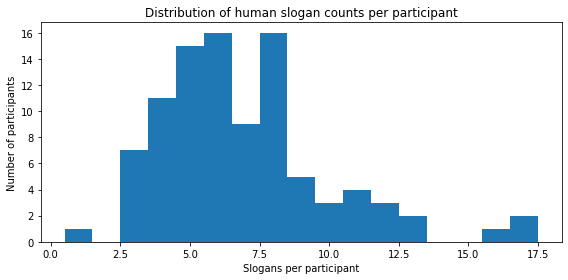

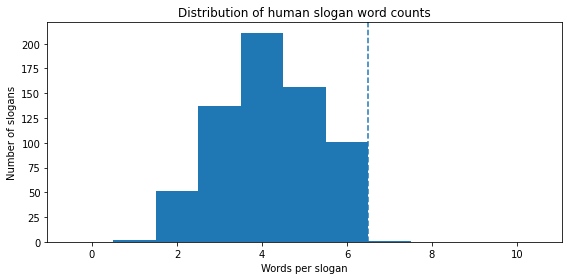

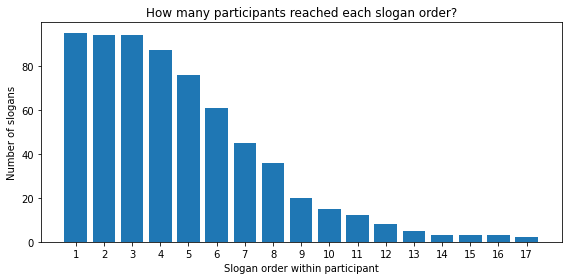

In [7]:
def plot_slogan_diagnostics(corpus: SloganCorpus) -> None:
    records = corpus.records
    participant_summary = corpus.participant_summary()

    plt.figure(figsize=(8, 4))
    bins = np.arange(1, participant_summary["n_slogans"].max() + 2) - 0.5
    plt.hist(participant_summary["n_slogans"], bins=bins)
    plt.xlabel("Slogans per participant")
    plt.ylabel("Number of participants")
    plt.title("Distribution of human slogan counts per participant")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    bins = np.arange(0, max(records["word_count"].max(), 10) + 2) - 0.5
    plt.hist(records["word_count"], bins=bins)
    plt.axvline(6.5, linestyle="--")
    plt.xlabel("Words per slogan")
    plt.ylabel("Number of slogans")
    plt.title("Distribution of human slogan word counts")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    order_counts = records["order"].value_counts().sort_index()
    plt.bar(order_counts.index.astype(str), order_counts.values)
    plt.xlabel("Slogan order within participant")
    plt.ylabel("Number of slogans")
    plt.title("How many participants reached each slogan order?")
    plt.tight_layout()
    plt.show()


plot_slogan_diagnostics(slogan_corpus)

In [8]:
human_slogan_df = slogan_corpus.records.copy()

print("Full human slogan dataset")
print(f"  Rows / slogans:     {len(human_slogan_df):,}")
print(f"  Participants:       {human_slogan_df['participant_id'].nunique():,}")
print(f"  Unique slogan text: {human_slogan_df['text'].nunique():,}")
print()
print(human_slogan_df["valid_slogan_heuristic"].value_counts(dropna=False))

human_slogan_df.head()

Full human slogan dataset
  Rows / slogans:     659
  Participants:       95
  Unique slogan text: 650

valid_slogan_heuristic
True     658
False      1
Name: count, dtype: int64


,slogan_id,source_row_idx,participant_id,condition_id,condition_label,product,order,text_raw,text,word_count_reported,word_count,char_count,line_count,created_at_raw,empty_text,over_6_words,reported_word_count_mismatch,looks_like_multiple_slogans,has_commentary,valid_slogan_heuristic
0,0,0,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,1,The future right in your pocket.,The future right in your pocket.,6,6,32,1,15:53.4,False,False,False,False,False,True
1,1,1,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,2,A phone for a new age.,A phone for a new age.,6,6,22,1,15:53.4,False,False,False,False,False,True
2,2,2,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,3,Slim. Sleek. Smartphone.,Slim. Sleek. Smartphone.,3,3,24,1,15:53.4,False,False,False,False,False,True
3,3,3,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,4,Be smart. Get this phone.,Be smart. Get this phone.,5,5,25,1,15:53.4,False,False,False,False,False,True
4,4,4,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,5,Smartphones just got a genius upgrade.,Smartphones just got a genius upgrade.,6,6,38,1,15:53.4,False,False,False,False,False,True


In [10]:
sampled_one_per_participant_df = slogan_corpus.sample_one_slogan_per_participant(
    random_state=42,
    condition_id="smartphone",
)

print("Sampled one slogan per participant")
print(f"  Rows:         {len(sampled_one_per_participant_df):,}")
print(f"  Participants: {sampled_one_per_participant_df['participant_id'].nunique():,}")

sampled_one_per_participant_df.head(20)

Sampled one slogan per participant
  Rows:         95
  Participants: 95


,slogan_id,source_row_idx,participant_id,condition_id,condition_label,product,order,text_raw,text,word_count_reported,word_count,char_count,line_count,created_at_raw,empty_text,over_6_words,reported_word_count_mismatch,looks_like_multiple_slogans,has_commentary,valid_slogan_heuristic
0,1,1,545cbbcafdf99b11ed040acf,smartphone,Smartphone,smartphone,2,A phone for a new age.,A phone for a new age.,6,6,22,1,15:53.4,False,False,False,False,False,True
1,8,8,562d4849733ea000111635ca,smartphone,Smartphone,smartphone,1,Life in your hands,Life in your hands,4,4,18,1,16:24.9,False,False,False,False,False,True
2,19,19,5753046ba6deb50006d64b0f,smartphone,Smartphone,smartphone,1,Power that keeps up,Power that keeps up,4,4,19,1,24:22.7,False,False,False,False,False,True
3,27,27,5781c15381f331000139a89e,smartphone,Smartphone,smartphone,2,Beautiful phones for beautiful minds.,Beautiful phones for beautiful minds.,5,5,37,1,19:01.4,False,False,False,False,False,True
4,31,31,5997b3f8d0bcd10001dd902a,smartphone,Smartphone,smartphone,3,Mr. or Ms. Chatterbox,Mr. or Ms. Chatterbox,4,4,21,1,06:21.8,False,False,False,False,False,True
5,35,35,5dd38420a71de83809342ca3,smartphone,Smartphone,smartphone,2,get some!,get some!,2,2,9,1,10:25.6,False,False,False,False,False,True
6,38,38,5dd5b42a2091e95798fbf574,smartphone,Smartphone,smartphone,1,The cutting edge in your pocket.,The cutting edge in your pocket.,6,6,32,1,05:30.2,False,False,False,False,False,True
7,45,45,5dd5e27fe25acf59990e1adf,smartphone,Smartphone,smartphone,2,"fast, featured, great battery life","fast, featured, great battery life",5,5,34,1,07:50.5,False,False,False,False,False,True
8,60,60,5e4566e8f64db704b739b757,smartphone,Smartphone,smartphone,8,Be Truly Smart,Be Truly Smart,3,3,14,1,08:42.7,False,False,False,False,False,True
9,64,64,5fc50bb38378c80ac88354ef,smartphone,Smartphone,smartphone,3,Very SMART ...ALL SO TRUE,Very SMART ...ALL SO TRUE,5,5,25,1,31:12.8,False,False,False,False,False,True


In [11]:
CACHE_DIR = Path("human_data/cache")
PILOT_DIR = Path("human_data/pilot")
SLOGAN_OUT_DIR = Path("human_data/sloganData/processed")

for p in [CACHE_DIR, PILOT_DIR, SLOGAN_OUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Reusable object.
corpus_pickle_path = CACHE_DIR / "slogan_corpus.pkl"
slogan_corpus.to_pickle(corpus_pickle_path)

# Full benchmark-ready human slogan data.
full_pkl = PILOT_DIR / "smartphone_human_slogans.pkl"
full_csv = PILOT_DIR / "smartphone_human_slogans.csv"

human_slogan_df.to_pickle(full_pkl)
human_slogan_df.to_csv(full_csv, index=False)

# Summary files.
condition_summary_csv = PILOT_DIR / "smartphone_human_slogan_condition_summary.csv"
participant_summary_csv = PILOT_DIR / "smartphone_human_slogan_participant_summary.csv"
duplicates_csv = PILOT_DIR / "smartphone_human_slogan_duplicate_summary.csv"

condition_summary.to_csv(condition_summary_csv, index=False)
participant_summary.to_csv(participant_summary_csv, index=False)
duplicate_summary.to_csv(duplicates_csv, index=False)

# Optional deterministic sampled view.
sampled_pkl = PILOT_DIR / "smartphone_human_slogans_one_per_participant_seed42.pkl"
sampled_csv = PILOT_DIR / "smartphone_human_slogans_one_per_participant_seed42.csv"

sampled_one_per_participant_df.to_pickle(sampled_pkl)
sampled_one_per_participant_df.to_csv(sampled_csv, index=False)

# Also save into source-specific processed directory.
human_slogan_df.to_pickle(SLOGAN_OUT_DIR / "smartphone_human_slogans.pkl")
human_slogan_df.to_csv(SLOGAN_OUT_DIR / "smartphone_human_slogans.csv", index=False)

print("Saved:")
print(corpus_pickle_path)
print(full_pkl)
print(full_csv)
print(condition_summary_csv)
print(participant_summary_csv)
print(duplicates_csv)
print(sampled_pkl)
print(sampled_csv)
print(SLOGAN_OUT_DIR / "smartphone_human_slogans.pkl")
print(SLOGAN_OUT_DIR / "smartphone_human_slogans.csv")

Saved:
human_data/cache/slogan_corpus.pkl
human_data/pilot/smartphone_human_slogans.pkl
human_data/pilot/smartphone_human_slogans.csv
human_data/pilot/smartphone_human_slogan_condition_summary.csv
human_data/pilot/smartphone_human_slogan_participant_summary.csv
human_data/pilot/smartphone_human_slogan_duplicate_summary.csv
human_data/pilot/smartphone_human_slogans_one_per_participant_seed42.pkl
human_data/pilot/smartphone_human_slogans_one_per_participant_seed42.csv
human_data/sloganData/processed/smartphone_human_slogans.pkl
human_data/sloganData/processed/smartphone_human_slogans.csv
